In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans


In [3]:
df = pd.read_csv('CovidTweets_features_bert 2.csv')

In [4]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols = numeric_cols[2:]

In [5]:
from sklearn.model_selection import train_test_split

X = df[numeric_cols]         
y = df['Sentiment']        

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)


In [6]:
pca = PCA(n_components=2, random_state=42)

X_train_pca = pca.fit_transform(X_train)
print(len(X_train_pca))
X_test_pca = pca.transform(X_test)

26973


In [7]:
train_df = X_train.copy()
train_df[['PCA_1','PCA_2']] = X_train_pca
train_df['Sentiment'] = y_train.values

test_df = X_test.copy()
test_df[['PCA_1','PCA_2']]  = X_test_pca
test_df['Sentiment'] = y_test.values

In [9]:
pca_cols = [col for col in train_df.columns if col in ['PCA_1', 'PCA_2']]
other_cols = [col for col in train_df.columns if col in ['word_count', 'ttr', 'nmf_topic', 'lda_topic', 'bertopic_topic']]

feature_cols = [col for col in train_df.select_dtypes(include='number').columns
                if col not in pca_cols + other_cols + ['label']]

print("Kolumny PCA:", pca_cols)
print("Inne kolumny", other_cols)
print("Kolumny cech:", feature_cols)

Kolumny PCA: ['PCA_1', 'PCA_2']
Inne kolumny ['word_count', 'ttr', 'nmf_topic', 'lda_topic', 'bertopic_topic']
Kolumny cech: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140

In [10]:
default_color_map = {
    'Extremely Negative': 'red',
    'Negative':           'orange',
    'Neutral':            'gray',
    'Positive':           'limegreen',
    'Extremely Positive': 'darkgreen'
}

In [11]:
def plot_sentiment_pca(df, pca_cols=('PCA_1','PCA_2'), sentiment_col='Sentiment', cmap=None):

    plt.figure(figsize=(9,6))
    if cmap:
        palette = cmap
    else:
        # domyślna paleta seaborn
        unique = df[sentiment_col].unique()
        palette = dict(zip(unique, sns.color_palette(n_colors=len(unique))))

    sns.scatterplot(
        data=df,
        x=pca_cols[0], y=pca_cols[1],
        hue=sentiment_col,
        palette=palette,
        s=15,
        alpha=0.7
    )
    plt.title('Sentiment in PCA space')
    plt.xlabel(pca_cols[0])
    plt.ylabel(pca_cols[1])
    plt.legend(title='Sentiment', bbox_to_anchor=(1.05,1), loc='upper left')
    plt.tight_layout()
    plt.show()

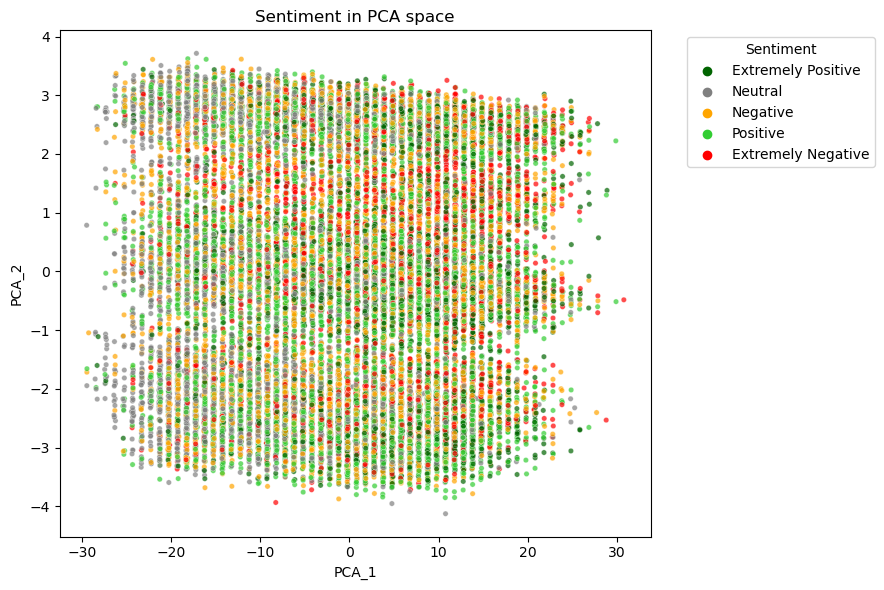

In [12]:
plot_sentiment_pca(train_df, cmap=default_color_map)

In [13]:
from umap import UMAP    
import matplotlib.pyplot as plt
import seaborn as sns

Index(['word_count', 'ttr', 'nmf_topic', 'lda_topic', 'bertopic_topic', '0',
       '1', '2', '3', '4',
       ...
       '760', '761', '762', '763', '764', '765', '766', '767', 'PCA_1',
       'PCA_2'],
      dtype='object', length=775)


c:\anaconda\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\anaconda\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


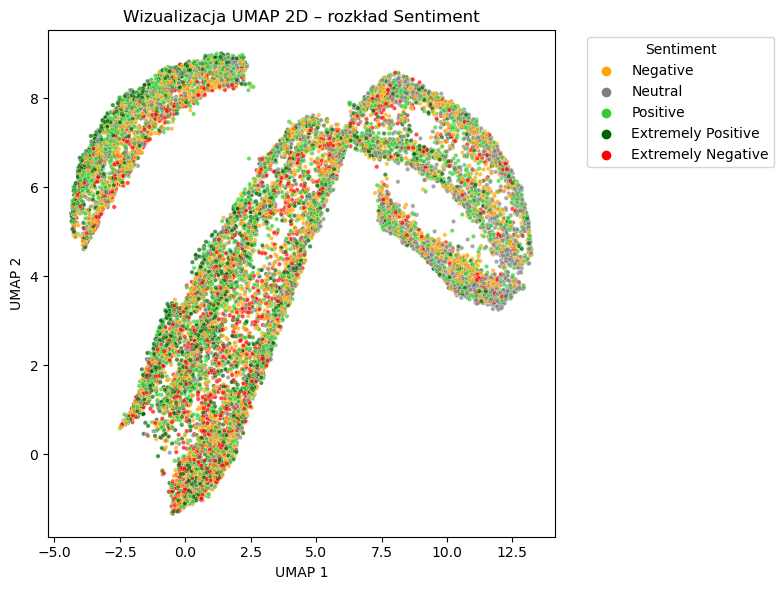

In [16]:
def plot_umap(df, feature_columns, n_neighbors=15, min_dist=0.1, n_components=2, metric='cosine'):


    data = df[feature_columns].values
    labels = df['Sentiment'].values
    print(df[feature_columns].columns)
    umap_model = UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=n_components,
        metric=metric,
        random_state=42
    )
    X_umap = umap_model.fit_transform(data)
    df[["UMAP1", "UMAP2"]] = X_umap

    plot_df = pd.DataFrame({
        'UMAP_1': X_umap[:, 0],
        'UMAP_2': X_umap[:, 1],
        'Sentiment': labels
    })

    color_map = {
        'Extremely Negative': 'red',
        'Negative':           'orange',
        'Neutral':            'gray',
        'Positive':           'limegreen',
        'Extremely Positive': 'darkgreen'
    }

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=plot_df,
        x='UMAP_1', y='UMAP_2',
        hue='Sentiment',
        palette=color_map,
        s=10,
        alpha=0.7
    )
    plt.title('Wizualizacja UMAP 2D – rozkład Sentiment')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


plot_umap(test_df, feature_cols)

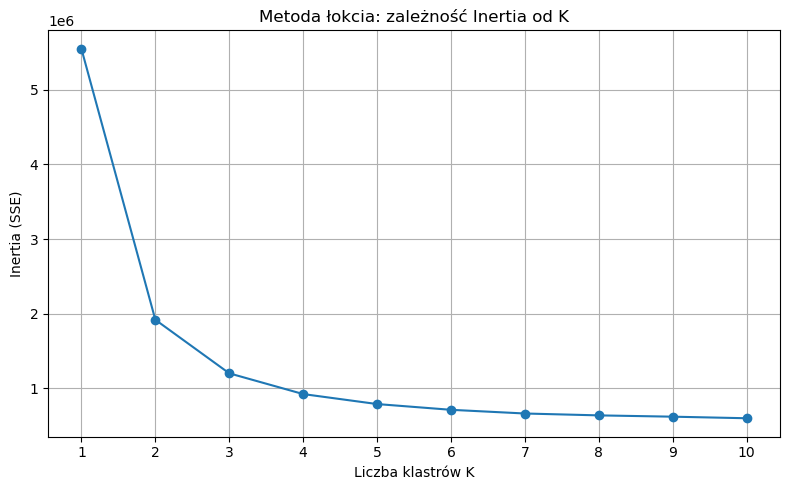

In [ ]:
umap_cols = ['UMAP_1', 'UMAP_2']
feature_cols = [
    col for col in test_df.select_dtypes(include='number').columns
    if col not in umap_cols + ['label']
]

X_test = test_df[feature_cols].values

inertias = []
ks = range(1, 11)

for k in ks:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_test)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(ks, inertias, marker='o', linestyle='-')
plt.xticks(ks)
plt.xlabel('Liczba klastrów K')
plt.ylabel('Inertia (SSE)')
plt.title('Metoda łokcia: zależność Inertia od K')
plt.grid(True)
plt.tight_layout()
plt.show()

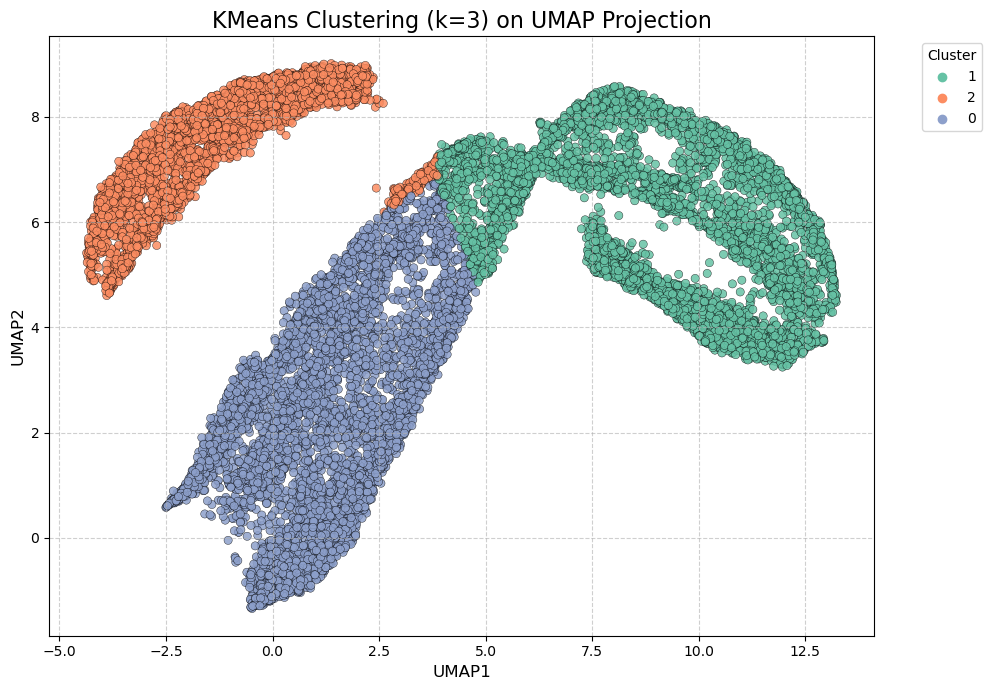

📊 Metryki klasteryzacji KMeans:

        Silhouette (train)  ARI_train  NMI_train   CH_train  DB_train
KMeans              0.5341     0.0281     0.0357  30505.083    0.7119


In [20]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, adjusted_rand_score,
    normalized_mutual_info_score, calinski_harabasz_score,
    davies_bouldin_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


label_mapping = {
    "Extremely Negative": 0,
    "Negative":           1,
    "Neutral":            2,
    "Positive":           3,
    "Extremely Positive": 4
}
test_df['label'] = test_df['Sentiment'].map(label_mapping)


umap_cols = ["UMAP1", "UMAP2"]
X_test = test_df[umap_cols].values
y_test = test_df['label'].values


kmeans = KMeans(n_clusters=3, random_state=42)
train_clusters = kmeans.fit_predict(X_test)

results = pd.DataFrame({
    'Silhouette (train)': [silhouette_score(X_test, train_clusters)],
    'ARI_train': [adjusted_rand_score(y_test, train_clusters)],
    'NMI_train': [normalized_mutual_info_score(y_test, train_clusters)],
    'CH_train': [calinski_harabasz_score(X_test, train_clusters)],
    'DB_train': [davies_bouldin_score(X_test, train_clusters)]
}, index=['KMeans'])


vis_df = test_df.copy()
vis_df['cluster'] = train_clusters.astype(str)

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=vis_df,
    x='UMAP1', y='UMAP2',
    hue='cluster',
    palette='Set2',  
    s=35,
    edgecolor='black',
    linewidth=0.3,
    alpha=0.85
)
plt.title('KMeans Clustering (k=3) on UMAP Projection', fontsize=16)
plt.xlabel('UMAP1', fontsize=12)
plt.ylabel('UMAP2', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("📊 Metryki klasteryzacji KMeans:\n")
print(results.round(4))


- Adjusted_rand_score : 0.0281
- normalized_mutual_info : 0.0357
- --------------
- Silhouette score : 0.5431
- Calinski_harabasz_score : 30505.03
- Davies_bouldin_score : 0.7119

In [19]:
pd.crosstab(vis_df['cluster'], vis_df['Sentiment'], normalize='index')




Sentiment,Extremely Negative,Extremely Positive,Negative,Neutral,Positive
cluster,,,,,
0,0.181062,0.215991,0.242052,0.090326,0.270569
1,0.084520,0.085719,0.241870,0.318298,0.269594
2,0.135176,0.184422,0.250000,0.137437,0.292965


- klaster 0 : mix
- klaster 1 : neutral
- klaster 2 : positive